## 1. Import Libraries and Load Cleaned Data

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from imblearn.combine import SMOTEENN
from sklearn.preprocessing import RobustScaler, OrdinalEncoder,LabelEncoder
from sklearn.metrics import roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import ExtraTreesClassifier

from module_function import (cross_validate_model,evalute_models_classification,feature_importance,plot_residuals,
                             Hyperparameter_Tuning,plot_tuned_feature_importance,plot_confusion_matrix,plot_roc_curves)

import warnings
warnings.filterwarnings("ignore")

import pickle

In [87]:
df = pd.read_csv('data/students_dropout_CLEANING.csv')
df_x = df.drop(columns='Target')
df_y = df['Target']

In [88]:
X_train,X_test,y_train,y_test = train_test_split(df_x,df_y,stratify=df_y,test_size=0.2,random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 561 samples
Test set: 141 samples


## 2.Feature Scaling

In [89]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns

base_preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_cols),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols)
    ]
)

target_encoder = LabelEncoder()
y_train_encoded = target_encoder.fit_transform(y_train)
y_test_encoded = target_encoder.transform(y_test)

print("--- Hasil Pemetaan Label Encoding ---")
for index, kelas in enumerate(target_encoder.classes_):
    print(f"Kategori: '{kelas}' diubah menjadi angka -> {index}")

--- Hasil Pemetaan Label Encoding ---
Kategori: 'Dropout' diubah menjadi angka -> 0
Kategori: 'Enrolled' diubah menjadi angka -> 1
Kategori: 'Graduate' diubah menjadi angka -> 2


## 3.Pipeline All Models Classification

In [90]:
n = 19
classification_pipelines = {
    'Logistic Regression (Baseline)': Pipeline([
        ('preprocessing', base_preprocessor),
        ('smoteenn', SMOTEENN(random_state=42)),
        ('feature_selection', SelectKBest(score_func=f_classif, k=n)),
        ('model', LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'))
    ]),
    
    'Random Forest Classifier': Pipeline([
        ('preprocessing', base_preprocessor),
        ('smoteenn', SMOTEENN(random_state=42)),
        ('feature_selection', SelectKBest(score_func=f_classif, k=n)),
        ('model', RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1))
    ]),
    
    'Extra Trees Classifier': Pipeline([
        ('preprocessing', base_preprocessor),
        ('smoteenn', SMOTEENN(random_state=42)),
        ('feature_selection', SelectKBest(score_func=f_classif, k=n)),
        ('model', ExtraTreesClassifier(random_state=42, n_estimators=100, n_jobs=-1, class_weight='balanced'))
    ]),
    
    'XGBoost Classifier': Pipeline([
        ('preprocessing', base_preprocessor),
        ('smoteenn', SMOTEENN(random_state=42)),
        ('feature_selection', SelectKBest(score_func=f_classif, k=n)),
        ('model', XGBClassifier(random_state=42, n_estimators=100, learning_rate=0.1, eval_metric='mlogloss', n_jobs=-1))
    ]),
    
    'LightGBM Classifier': Pipeline([
        ('preprocessing', base_preprocessor),
        ('smoteenn', SMOTEENN(random_state=42)),
        ('feature_selection', SelectKBest(score_func=f_classif, k=n)),
        ('model', LGBMClassifier(random_state=42, n_estimators=100, learning_rate=0.1, n_jobs=-1, verbose=-1))
    ]),
    
    'CatBoost Classifier': Pipeline([
        ('preprocessing', base_preprocessor),
        ('smoteenn', SMOTEENN(random_state=42)),
        ('feature_selection', SelectKBest(score_func=f_classif, k=n)),
        ('model', CatBoostClassifier(random_state=42, iterations=100, learning_rate=0.1, verbose=0))
    ]),
    
    'Hist Gradient Boosting': Pipeline([
        ('preprocessing', base_preprocessor),
        ('smoteenn', SMOTEENN(random_state=42)),
        ('feature_selection', SelectKBest(score_func=f_classif, k=n)),
        ('model', HistGradientBoostingClassifier(random_state=42, max_iter=100, learning_rate=0.1))
    ]),
    
    'Support Vector Classifier (SVC)': Pipeline([
        ('preprocessing', base_preprocessor),
        ('smoteenn', SMOTEENN(random_state=42)),
        ('feature_selection', SelectKBest(score_func=f_classif, k=n)),
        ('model', SVC(random_state=42, probability=True, kernel='rbf', class_weight='balanced'))
    ]),

    'K-Nearest Neighbors (KNN)': Pipeline([
        ('preprocessing', base_preprocessor),
        ('smoteenn', SMOTEENN(random_state=42)),
        ('feature_selection', SelectKBest(score_func=f_classif, k=n)),
        ('model', KNeighborsClassifier(n_neighbors=5, n_jobs=-1))
    ])
}

## 4.Analysis Model Sebelum Cross-Validate

In [91]:
predictions_dict = {}
for model_name, pipeline in classification_pipelines.items():
    pipeline.fit(X_train, y_train_encoded)
    y_pred = pipeline.predict(X_test)
    predictions_dict[model_name] = y_pred

df_report = evalute_models_classification( model_dict=predictions_dict, y_test=y_test_encoded,averages='macro')
df_report.sort_values(by='Accuracy', ascending=False)

Menguji model: Logistic Regression (Baseline)
=== CLASSIFICATION REPORT: Logistic Regression (Baseline) ===
              precision    recall  f1-score   support

           0       0.20      0.54      0.29        13
           1       0.32      0.41      0.36        29
           2       0.94      0.66      0.77        99

    accuracy                           0.60       141
   macro avg       0.49      0.54      0.48       141
weighted avg       0.75      0.60      0.64       141



Menguji model: Random Forest Classifier
=== CLASSIFICATION REPORT: Random Forest Classifier ===
              precision    recall  f1-score   support

           0       0.27      0.23      0.25        13
           1       0.39      0.72      0.51        29
           2       0.91      0.70      0.79        99

    accuracy                           0.66       141
   macro avg       0.52      0.55      0.51       141
weighted avg       0.74      0.66      0.68       141



Menguji model: Extra Trees Cla

,Model,Accuracy,Precision,Recall,F1-Score
4,LightGBM Classifier,0.680851,0.577982,0.605275,0.570732
1,Random Forest Classifier,0.659574,0.523170,0.550626,0.514865
3,XGBoost Classifier,0.645390,0.526389,0.564058,0.527378
7,Support Vector Classifier (SVC),0.638298,0.496641,0.532397,0.493264
6,Hist Gradient Boosting,0.638298,0.475928,0.501996,0.472316
2,Extra Trees Classifier,0.624113,0.499394,0.517536,0.487001
5,CatBoost Classifier,0.609929,0.465303,0.488528,0.453713
0,Logistic Regression (Baseline),0.595745,0.488784,0.536273,0.476371
8,K-Nearest Neighbors (KNN),0.446809,0.422670,0.412891,0.364634


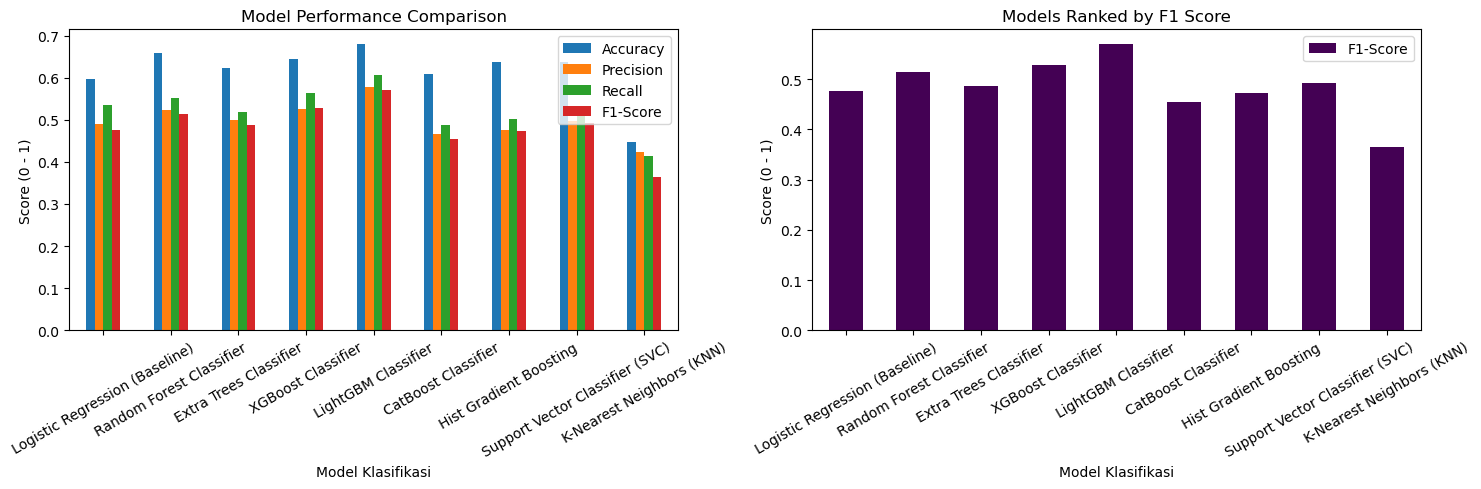

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
df_report.set_index('Model')[['Accuracy', 'Precision','Recall','F1-Score']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Model Performance Comparison', fontsize=12)
axes[0].set_ylabel('Score (0 - 1)')
axes[0].set_xlabel('Model Klasifikasi')
axes[0].tick_params(axis='x', rotation=30)

df_report.set_index('Model')[['F1-Score']].plot(kind='bar', ax=axes[1], colormap='viridis')
axes[1].set_title('Models Ranked by F1 Score', fontsize=12)
axes[1].set_ylabel('Score (0 - 1)')
axes[1].set_xlabel('Model Klasifikasi')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

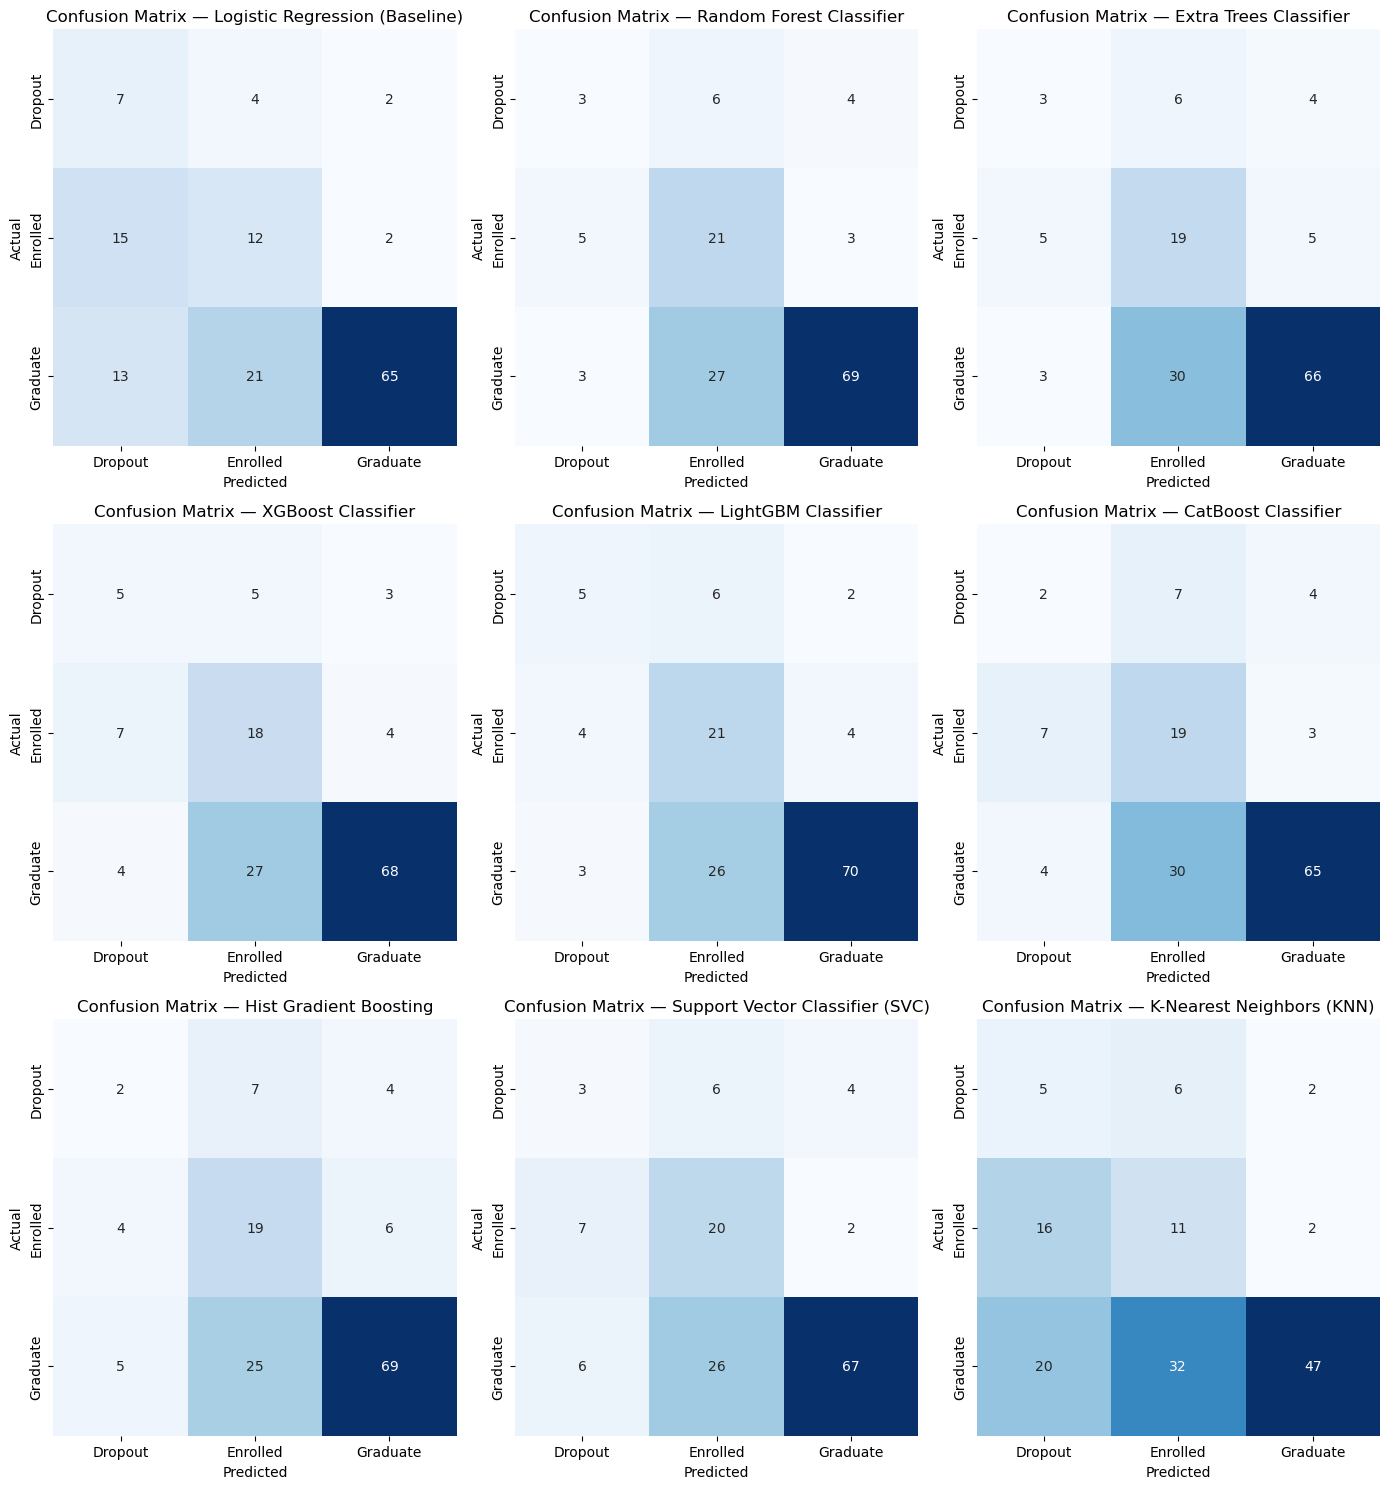

In [93]:
label = ['Dropout','Enrolled','Graduate',]
plot_confusion_matrix(model_dict=predictions_dict,y_test=y_test_encoded,labels=label)

## 5.Analysis Model Sesudah Cross-Validate

In [94]:
df_hasil_perbandingan = cross_validate_model(models_dict=classification_pipelines, X=X_train, y=y_train_encoded, cv_folds=5, mode='classification')
df_hasil_perbandingan.sort_values(by='Accuracy', ascending=False)

=== MENJALANKAN STRATIFIED 5-FOLD CROSS VALIDATION (KLASIFIKASI) ===

Menguji model: Logistic Regression (Baseline)
Menguji model: Random Forest Classifier
Menguji model: Extra Trees Classifier
Menguji model: XGBoost Classifier
Menguji model: LightGBM Classifier
Menguji model: CatBoost Classifier
Menguji model: Hist Gradient Boosting
Menguji model: Support Vector Classifier (SVC)
Menguji model: K-Nearest Neighbors (KNN)

Proses CV Selesai!


,Model,Accuracy,Precision,Recall,F1-Score
4,LightGBM Classifier,0.634655,0.480696,0.508295,0.480361
7,Support Vector Classifier (SVC),0.622171,0.474363,0.505001,0.472063
6,Hist Gradient Boosting,0.620417,0.471389,0.499045,0.472656
2,Extra Trees Classifier,0.613148,0.470983,0.496862,0.464751
1,Random Forest Classifier,0.607854,0.449717,0.473426,0.443334
3,XGBoost Classifier,0.598989,0.439969,0.458520,0.436975
0,Logistic Regression (Baseline),0.584655,0.459864,0.478473,0.444536
5,CatBoost Classifier,0.566846,0.456896,0.484906,0.439961
8,K-Nearest Neighbors (KNN),0.395875,0.422538,0.410755,0.343859


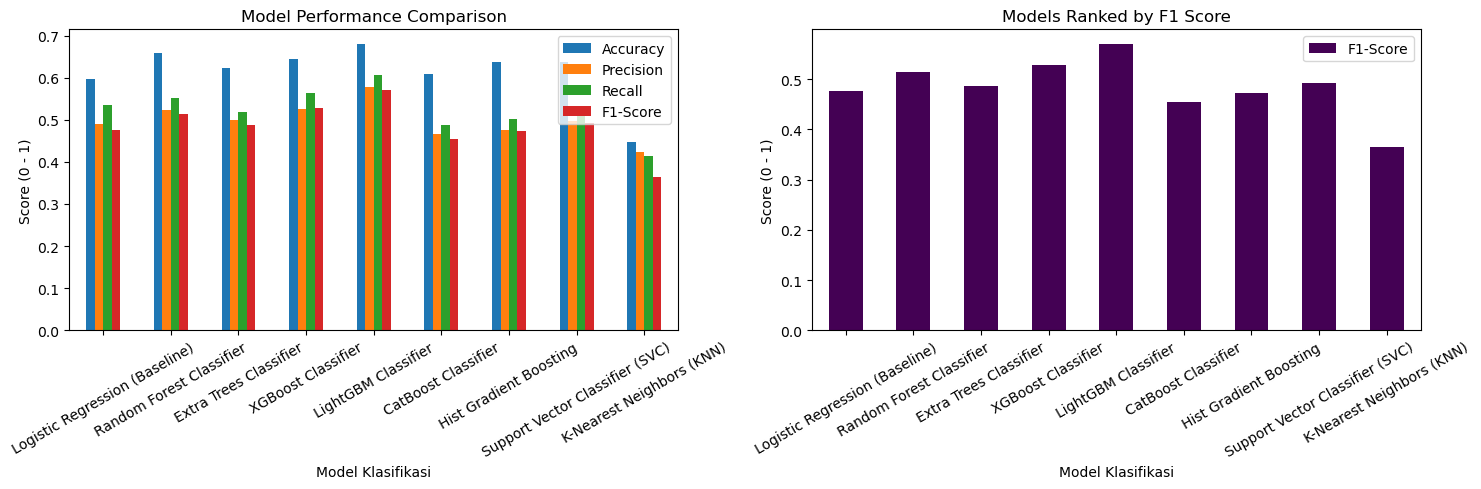

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
df_report.set_index('Model')[['Accuracy', 'Precision','Recall','F1-Score']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Model Performance Comparison', fontsize=12)
axes[0].set_ylabel('Score (0 - 1)')
axes[0].set_xlabel('Model Klasifikasi')
axes[0].tick_params(axis='x', rotation=30)

df_report.set_index('Model')[['F1-Score']].plot(kind='bar', ax=axes[1], colormap='viridis')
axes[1].set_title('Models Ranked by F1 Score', fontsize=12)
axes[1].set_ylabel('Score (0 - 1)')
axes[1].set_xlabel('Model Klasifikasi')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 6. Analysis Nilai Asli dan Nilai Prediksi

In [96]:
model_lgb = classification_pipelines['LightGBM Classifier']
y_pred_proba = model_lgb.predict_proba(X_test)

# 2. Hitung nilai ROC-AUC dengan menentukan strategi multiclass ('ovr' atau 'ovo')
macro_roc_auc = roc_auc_score(y_test_encoded, y_pred_proba, multi_class='ovr', average='macro')
print(f"Multiclass Macro ROC-AUC Score: {macro_roc_auc:.4f}")

Multiclass Macro ROC-AUC Score: 0.7895


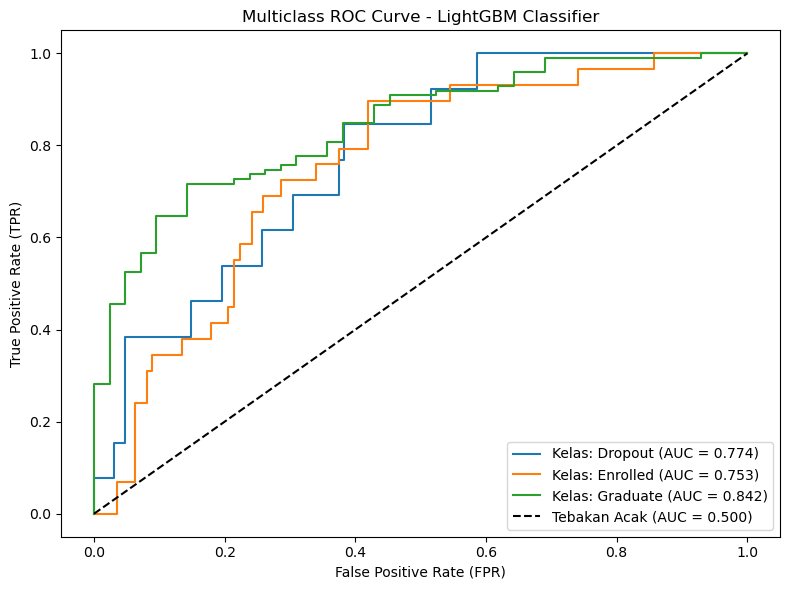

In [100]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

def plot_roc_curves(model_dict,X_test,y_test,target_encoder):
    classes = np.unique(y_test)
    n_classes = len(classes)

    class_names = target_encoder.classes_
    y_test_bin = label_binarize(y_test, classes=classes)

    for name, pipeline in model_dict.items():
        plt.figure(figsize=(8, 6))
        
        # Ambil nilai probabilitas untuk semua kelas
        if hasattr(pipeline, 'predict_proba'):
            y_prob = pipeline.predict_proba(X_test)
        else:
            # Jika menggunakan model berbasis decision_function seperti SVC tanpa probability=True
            y_prob = pipeline.decision_function(X_test)
        
        # Loop untuk menggambar kurva ROC tiap-tiap kelas pada model aktif
        for i in range(n_classes):
            # Ambil data aktual kolom ke-i dan probabilitas kolom ke-i
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
            roc_auc = auc(fpr, tpr)
            
            # Plot kurva untuk kelas spesifik ini
            plt.plot(fpr, tpr, label=f"Kelas: {class_names[i]} (AUC = {roc_auc:.3f})")
            
        # Pengaturan kosmetik grafik untuk model ini
        plt.plot([0, 1], [0, 1], "k--", label="Tebakan Acak (AUC = 0.500)")
        plt.xlabel("False Positive Rate (FPR)")
        plt.ylabel("True Positive Rate (TPR)")
        plt.title(f"Multiclass ROC Curve - {name}")
        plt.legend(loc="lower right")
        plt.tight_layout()
        plt.show()

model_lgb = classification_pipelines['LightGBM Classifier']
plot_roc_curves(model_dict={'LightGBM Classifier': model_lgb},X_test=X_test,y_test=y_test_encoded,target_encoder=target_encoder)